In [2]:
# from models.preprocessors import BoundingBoxEngineering
from PIL import Image
import pandas as pd
import numpy as np

In [1]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from ultralytics import YOLO
from PIL import Image

import pandas as pd
import numpy as np
import torch
import gc
import uuid

class BoundingBoxEngineering(BaseEstimator, TransformerMixin):
    def __init__(self, model = "yolo11n.pt", batch_size = 10, dsample = 128, max_boxes = 10, conf=.1):
        """
        A custom transformer that uses a pre-trained YOLO model to detect pedestrians
        and traffic lights in images, and transforms each image into a list of cropped objects with metadata.
        Args:
            model: The name of the pre-trained YOLO model to use (default: "yolo11n.pt").
            batch_size: The number of images to process in a batch (default: 10).
            dsample: The size to which each cropped object will be resized (default: 128).
            max_boxes: The maximum number of objects to detect and crop from each image (default: 10).
        """
        super().__init__()
        self.model = YOLO(model)
        self.batch_size = batch_size
        self.dsample = (dsample, dsample)
        self.max_boxes = max_boxes
        self.conf = conf

    def fit(self, X, y=None):
        return self

    def fit_transform(self, X, y = None, **fit_params):
        return super().fit_transform(X, y, **fit_params)
    
    def transform(self, X):
        """
        For each image, run the YOLO model to detect pedestrians and traffic 
        lights. For each detected object, crop the image to a square around 
        the bounding box, resize it to 128x128, and concatenate the bounding 
        box coordinates and class label to the pixel values. Return a list 
        of frames, where each frame is a list of cropped objects.

        Args:
            X: A list of file paths to images.
            y: Ignored.

        Returns:
            A list of frames (shape = (n, 10, 128, 128, 8)), where each frame is a 
            list of cropped objects. Each cropped object is a 128x128x8 array, 
            where the first 3 channels are the pixel values, and the last 5 
            channels are the normalized bounding box coordinates and class label.
        """
        shape = (len(X), self.max_boxes, *self.dsample, 8)
        if len(X) > 1000:
            memmap_name = str(uuid.uuid4())
            frames = np.memmap(f'{memmap_name}.dat', dtype='float16', mode='w+', shape=shape)
        else:
            frames = np.zeros(shape, dtype=np.float32)
        
        for i in range(0, len(X), self.batch_size):
            batch_paths = X[i : i + self.batch_size]
            results = self.model(batch_paths, stream=True, conf = self.conf, verbose=False)
            
            for idx, result in enumerate(results):
                global_id = i + idx
                image = result.orig_img[:, :, ::-1]
                W, H = image.shape[1], image.shape[0]
                frame = np.zeros((self.max_boxes, *self.dsample, 8), dtype=np.float32)
                
                boxes   = result.boxes.xywh.cpu().numpy()
                classes = result.boxes.cls.cpu().numpy()

                order   = np.argsort(boxes[:,2] * boxes[:,3])[::-1]
                boxes   = boxes[order]
                classes = classes[order]

                i = 0
                for box, cls in zip(boxes, classes):
                    if i >= self.max_boxes:
                        break
                    if cls not in [0, 9]:
                        continue
                    x, y, w, h = box
                    
                    cls = (1 if cls == 0 else -1)
                    side = max(w, h)

                    x1 = int(max(0, x - side / 2))
                    y1 = int(max(0, y - side / 2))
                    x2 = int(min(W, x + side / 2))
                    y2 = int(min(H, y + side / 2))

                    crop = image[y1:y2, x1:x2]
                    
                    if crop.size == 0:
                        continue
                        
                    crop_resized = np.array(Image.fromarray(crop).resize(self.dsample, Image.LANCZOS)).astype(np.float32) / 255.0
                    meta = np.array([x/W, y/H, w/W, h/H, cls/1], dtype=np.float32)
                    
                    frame[i] = np.concatenate([crop_resized, np.tile(meta, (*self.dsample, 1))], axis=-1)
                    i += 1
                frames[global_id] = frame

            if i % 100 == 0:
                gc.collect()
                torch.cuda.empty_cache()

        return frames

In [8]:
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import pandas as pd

W, H = 1920, 1080
# Read the annotations
bboxes  = pd.read_csv(
    "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/bboxes.csv", 
    converters={ 'frame': lambda x: f"{int(x):05d}" },
    usecols=['video','frame','x1', 'y1', 'x2', 'y2', 'content', 'state', 'gesture', 'cross', 'look']
)
bboxes['x'] = ((bboxes.x1 + bboxes.x2) / 2) / W
bboxes['y'] = ((bboxes.y1 + bboxes.y2) / 2) / H
bboxes['w'] = (bboxes.x2 - bboxes.x1) / W
bboxes['h'] = (bboxes.y2 - bboxes.y1) / H
bboxes['cls'] = bboxes.content.apply(lambda x: 1 if x == 'pedestrian' else -1)

vehicles  = pd.read_csv(
    "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vehicles.csv", 
    converters={ 'frame': lambda x: f"{int(x):05d}" },
    usecols=['video','frame', 'GPS_speed']
)

data = bboxes.merge(vehicles, on=['video','frame']).fillna(0)
def metadata(group, limit):
    actual = group[['x1','x2','y1','y2','x', 'y', 'w', 'h', 'cls', 'state', 'gesture', 'cross', 'look', 'GPS_speed']].fillna(0.0).values.astype(np.float16)
    if len(actual) > limit:
        return actual[:limit, :]
    padding = np.pad(actual, ((0, limit - len(actual)), (0, 0)), mode='constant', constant_values=0.0).astype(np.float16)
    return padding

limit  = 5
frames = (data.groupby(['video', 'frame'])
          .apply(lambda group: metadata(group, limit), include_groups=False)
          .reset_index(name='metadata'))

N = len([1 for i, _ in frames.iterrows() if i % 5 == 0])
print(N)
results = np.memmap('vectorized-video-frames-labelled.dat', dtype='float16', mode='w+', shape=(N, 5, 128, 128, 13))
j = 0
folder = "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/images/set01"
for i, frame in frames.iterrows():
    if i % 5 != 0:
        continue
    boxes = np.zeros((limit, 128, 128, 13), dtype=np.float16)
    file  = f"{folder}/{frame.video}/{frame.frame}.png"
    img   = Image.open(f"{folder}/{frame.video}/{frame.frame}.png")
    
    for i, box in enumerate(frame.metadata):
        (x1, x2, y1, y2), labels = box[:4], box[4:]
        
        x = ((x1 + x2) / 2)
        y = ((y1 + y2) / 2)
        w = (x2 - x1) 
        h = (y2 - y1) 

        side = max(w, h) * 1.2

        x1 = int(max(0, x - side / 2))
        y1 = int(max(0, y - side / 2))
        x2 = int(min(W, x + side / 2))
        y2 = int(min(H, y + side / 2))

        crop = np.array(img.crop((x1, y1, x2, y2)).resize((128, 128), Image.LANCZOS)) / 255.
        boxes[i, :, :, :3] = crop
        boxes[i, :, :, 3:] = labels
    results[j] = boxes
    j += 1



3810


Importing instructions
```python
path = './vectorized-video-frames-labelled.dat'
results = np.memmap(path, dtype='float16', mode='r', shape=(3810, 5, 128, 128, 13))
```

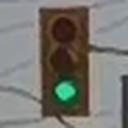

In [10]:
Image.fromarray((results[1, 0, :, :, :3] * 225).astype(np.uint8))